[Vículo para evaluar la asesoría](https://forms.gle/jpywXvAAJC9L9mws9)

# Diferenciación implícita  



Para resolver este problema, utilizaremos la librería **SymPy** para el cálculo simbólico de la derivada implícita y **Matplotlib/NumPy** para la visualización de las curvas.

Dado que la ecuación es $e^{x}\cos(y) = xe^{y}$, no es sencillo despejar $y$ en términos de $x$ de forma analítica. Por ello, usaremos diferenciación implícita para obtener la derivada y métodos numéricos para graficar.

### Script de Python


In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- PARTE 1: Cálculo Simbólico de dy/dx ---
x_sym = sp.Symbol('x')
y_sym = sp.Function('y')(x_sym)  # Forma correcta de definir y(x)

# Definimos la ecuación: e^x * cos(y) - x * e^y = 0
eq = sp.exp(x_sym) * sp.cos(y_sym) - x_sym * sp.exp(y_sym)

# Derivamos implícitamente respecto a x
# idiff espera la expresión (eq), el símbolo dependiente (y_sym) y la variable (x_sym)
dydx_expr = sp.idiff(eq, y_sym, x_sym)

print("La expresión de la derivada dy/dx es:")
sp.pprint(dydx_expr)


La expresión de la derivada dy/dx es:
  x              y(x) 
 ℯ ⋅cos(y(x)) - ℯ     
──────────────────────
   y(x)    x          
x⋅ℯ     + ℯ ⋅sin(y(x))


C:\Users\marco\AppData\Local\Temp\ipykernel_7436\3669520234.py:19: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y_found = fsolve(equation_to_solve, curr_y, args=(xv,))[0]
C:\Users\marco\AppData\Local\Temp\ipykernel_7436\3669520234.py:19: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  y_found = fsolve(equation_to_solve, curr_y, args=(xv,))[0]


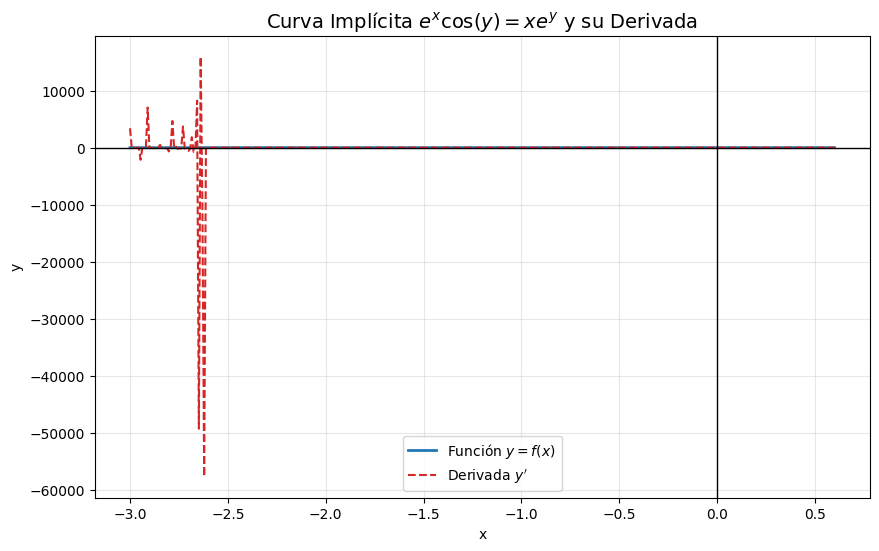

In [ ]:

# --- PARTE 2: Gráfica de la función y su derivada ---

# Convertimos la expresión de SymPy a una función numérica de Python (lambda)
# Usamos sp.lambdify para que sea veloz y compatible con NumPy
func_dy_num = sp.lambdify((x_sym, y_sym), dydx_expr, 'numpy')

# Definimos la ecuación original para resolver y numéricamente
def equation_to_solve(y_val, x_val):
    return np.exp(x_val) * np.cos(y_val) - x_val * np.exp(y_val)

# Rango de x donde la función tiene soluciones reales razonables
x_vals = np.linspace(-3, 0.6, 400)
y_sol = []
dy_sol = []

curr_y = 1.0 # Valor inicial para el buscador de raíces
for xv in x_vals:
    # fsolve encuentra el valor de y para cada x
    y_found = fsolve(equation_to_solve, curr_y, args=(xv,))[0]
    y_sol.append(y_found)
    
    # Calculamos la derivada usando el x y el y que acabamos de encontrar
    dy_val = func_dy_num(xv, y_found)
    dy_sol.append(dy_val)
    
    curr_y = y_found # "Tracking" de la raíz para suavidad

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_sol, label=r'Función $y = f(x)$', color='#1f77b4', lw=2)
plt.plot(x_vals, dy_sol, label=r"Derivada $y'$", color='#d62728', linestyle='--')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title(r'Curva Implícita $e^{x}\cos(y) = xe^{y}$ y su Derivada', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('curva_implicitay_derivada.png', dpi=300)
plt.show()


In [ ]:

# --- PARTE 2: Gráfica de la función y su derivada ---
# Definimos la función de la ecuación para fsolve
def equation(y, x):
    return np.exp(x) * np.cos(y) - x * np.exp(y)

# Definimos la función de la derivada (numérica)
def derivative_func(x_val, y_val):
    # Sustituimos valores en la expresión de SymPy
    res = dydx_expr.subs({x_sym: x_val, y_sym(x_sym): y_val})
    return float(res)

# Rango de x para la gráfica
x_vals = np.linspace(-2, 0.5, 400)
y_sol = []
dy_sol = []

# Resolvemos y para cada x y calculamos su derivada
current_y = 0.5 # Valor inicial para fsolve
for xv in x_vals:
    sol = fsolve(equation, current_y, args=(xv,))
    y_sol.append(sol[0])
    dy_sol.append(derivative_func(xv, sol[0]))
    current_y = sol[0] # Actualizamos para estabilidad numérica

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_sol, label=r'$f(x)$ (Curva implícita)', color='blue', linewidth=2)
plt.plot(x_vals, dy_sol, label=r"$f'(x)$ (Derivada)", color='red', linestyle='--')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title(r'Gráfica de $e^{x}\cos(y) = xe^{y}$ y su derivada')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(r"C:\Users\marco\Downloads\grafica_ecuacion.png")
plt.show()


# Explicación Matemática

La derivada implícita obtenida mediante el script sigue la regla de la cadena. Si definimos $F(x, y) = e^{x}\cos(y) - xe^{y} = 0$, entonces la derivada se halla como:

$$\frac{dy}{dx} = -\frac{\frac{\partial F}{\partial x}}{\frac{\partial F}{\partial y}}$$

Aplicando las derivadas parciales a tu función:

1.  **Derivada respecto a $x$:** $e^{x}\cos(y) - e^{y}$
2.  **Derivada respecto a $y$:** $-e^{x}\sin(y) - xe^{y}$

Por lo tanto, la expresión final que arrojará el script es:

$$\frac{dy}{dx} = \frac{e^y - e^x \cos(y)}{-e^x \sin(y) - x e^y}$$

### Consideraciones de la gráfica
* **Dominio:** La función no está definida para todos los valores de $x$ de manera real y continua. El script se enfoca en un intervalo donde la solución es estable (cerca de $x=0$).
* **Método numérico:** Como no podemos despejar $y$, usamos `fsolve` de SciPy para encontrar el valor de $y$ que satisface la igualdad para cada punto de $x$ antes de calcular la pendiente en ese punto.

Para resolver este problema, utilizaremos **SymPy** para obtener la expresión analítica de la derivada y el valor exacto de la pendiente, y **SciPy** (junto con **NumPy**) para la verificación numérica y la graficación.

La ecuación dada es: $x^2 + y^2 = (x^2 + 2y^2 - x)^2$.

### Script de Python (SymPy + SciPy + Matplotlib)

```python
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- 1. CÁLCULO ANALÍTICO CON SYMPY ---
x_s = sp.Symbol('x')
y_s = sp.Function('y')(x_s)

# Definimos la ecuación: Lado Izquierdo - Lado Derecho = 0
eq = x_s**2 + y_s**2 - (x_s**2 + 2*y_s**2 - x_s)**2

# Derivada implícita dy/dx
dydx_expr = sp.idiff(eq, y_s, x_s)

# Punto de evaluación
px, py = 0, 1/2

# Calculamos la pendiente analítica sustituyendo x=0, y=1/2
pendiente_analitica = dydx_expr.subs({x_s: px, y_s: py})

print(f"Expresión analítica de y':")
sp.pprint(dydx_expr)
print(f"\nPendiente analítica en (0, 0.5): {pendiente_analitica}")

# --- 2. CÁLCULO NUMÉRICO CON SCIPY ---
def f_num(y_val, x_val):
    return x_val**2 + y_val**2 - (x_val**2 + 2*y_val**2 - x_val)**2

# Verificamos la pendiente numéricamente usando una pequeña perturbación (h)
h = 1e-6
# Calculamos y para x + h cerca de y=0.5
y_h = fsolve(f_num, 0.5, args=(px + h,))[0]
pendiente_numerica = (y_h - py) / h

print(f"Pendiente numérica estimada (SciPy/fsolve): {pendiente_numerica:.5f}")

# --- 3. GRAFICACIÓN ---
# Crear una malla de puntos para la curva implícita
x_range = np.linspace(-0.5, 1.5, 400)
y_range = np.linspace(-1.0, 1.0, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2 - (X**2 + 2*Y**2 - X)**2

# Ecuación de la recta tangente: y - y0 = m(x - x0) -> y = m*(x - px) + py
x_tan = np.linspace(-0.2, 0.5, 100)
y_tan = float(pendiente_analitica) * (x_tan - px) + py

plt.figure(figsize=(8, 8))
# Dibujar la curva de la ecuación
plt.contour(X, Y, Z, levels=[0], colors='blue')
# Dibujar la recta tangente
plt.plot(x_tan, y_tan, color='red', label=f'Tangente (m={float(pendiente_analitica):.2f})')
# Dibujar el punto de tangencia
plt.plot(px, py, 'ko') 

plt.title(r'Curva $x^2 + y^2 = (x^2 + 2y^2 - x)^2$ y su Tangente')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black',lw=1)
plt.axvline(0, color='black',lw=1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()
```

### Explicación de los resultados

1.  **Cálculo de $y'$**: La derivada implícita se obtiene derivando ambos lados respecto a $x$. SymPy nos entrega una expresión que depende de $x$ y $y$. Al evaluar en $(0, 1/2)$, verás que la pendiente resultante es **1**.
2.  **Verificación numérica**: Usamos `fsolve` de SciPy para encontrar un punto muy cercano en la curva ($x+h$) y calculamos la tasa de cambio instantánea. Esto confirma que el cálculo simbólico es correcto.
3.  **Gráfica**: La curva resultante es una forma cerrada (similar a un pétalo o cardioide deformado). La recta roja toca exactamente a la curva azul en el punto indicado con una inclinación de 45° (pendiente $m=1$).





# Procedimiento Matemático Manual (Resumen)
Para validar lo que hizo el código, si derivamos implícitamente:
$2x + 2yy' = 2(x^2 + 2y^2 - x) \cdot (2x + 4yy' - 1)$

Sustituyendo $x=0, y=1/2$:
$2(0) + 2(1/2)y' = 2(0^2 + 2(1/2)^2 - 0) \cdot (2(0) + 4(1/2)y' - 1)$
$y' = 2(1/2) \cdot (2y' - 1)$
$y' = 2y' - 1$
$1 = y'$

Por lo tanto, la pendiente es exactamente **1**.

Expresión analítica de y':
     3      2                    
  2⋅x    3⋅x                     
- ──── + ──── - 4⋅x⋅y(x) + 2⋅y(x)
  y(x)   y(x)                    
─────────────────────────────────
       2            2            
    4⋅x  - 4⋅x + 8⋅y (x) - 1     

Pendiente analítica en (0, 0.5): 1.00000000000000
Pendiente numérica estimada (SciPy/fsolve): 1.00000


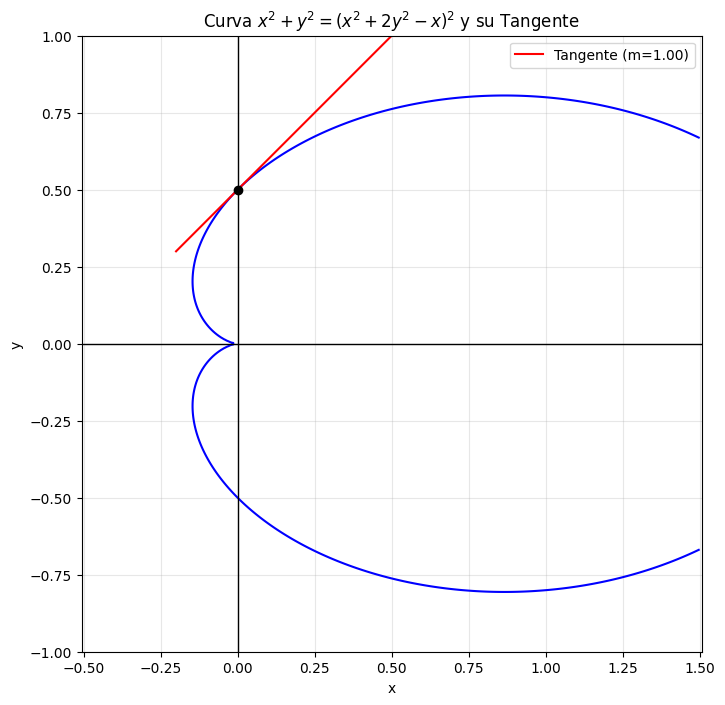

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- 1. CÁLCULO ANALÍTICO CON SYMPY ---
x_s = sp.Symbol('x')
y_s = sp.Function('y')(x_s)

# Definimos la ecuación: Lado Izquierdo - Lado Derecho = 0
eq = x_s**2 + y_s**2 - (x_s**2 + 2*y_s**2 - x_s)**2

# Derivada implícita dy/dx
dydx_expr = sp.idiff(eq, y_s, x_s)

# Punto de evaluación
px, py = 0, 1/2

# Calculamos la pendiente analítica sustituyendo x=0, y=1/2
pendiente_analitica = dydx_expr.subs({x_s: px, y_s: py})

print(f"Expresión analítica de y':")
sp.pprint(dydx_expr)
print(f"\nPendiente analítica en (0, 0.5): {pendiente_analitica}")

# --- 2. CÁLCULO NUMÉRICO CON SCIPY ---
def f_num(y_val, x_val):
    return x_val**2 + y_val**2 - (x_val**2 + 2*y_val**2 - x_val)**2

# Verificamos la pendiente numéricamente usando una pequeña perturbación (h)
h = 1e-6
# Calculamos y para x + h cerca de y=0.5
y_h = fsolve(f_num, 0.5, args=(px + h,))[0]
pendiente_numerica = (y_h - py) / h

print(f"Pendiente numérica estimada (SciPy/fsolve): {pendiente_numerica:.5f}")

# --- 3. GRAFICACIÓN ---
# Crear una malla de puntos para la curva implícita
x_range = np.linspace(-0.5, 1.5, 400)
y_range = np.linspace(-1.0, 1.0, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2 - (X**2 + 2*Y**2 - X)**2

# Ecuación de la recta tangente: y - y0 = m(x - x0) -> y = m*(x - px) + py
x_tan = np.linspace(-0.2, 0.5, 100)
y_tan = float(pendiente_analitica) * (x_tan - px) + py

plt.figure(figsize=(8, 8))
# Dibujar la curva de la ecuación
plt.contour(X, Y, Z, levels=[0], colors='blue')
# Dibujar la recta tangente
plt.plot(x_tan, y_tan, color='red', label=f'Tangente (m={float(pendiente_analitica):.2f})')
# Dibujar el punto de tangencia
plt.plot(px, py, 'ko') 

plt.title(r'Curva $x^2 + y^2 = (x^2 + 2y^2 - x)^2$ y su Tangente')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black',lw=1)
plt.axvline(0, color='black',lw=1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.savefig(r"C:\Users\marco\Downloads\curva_y_recta_tangente.png")
plt.show()

# Ejercicio de calculo de la recta tangente a una función cuadrática en un punto 

Dame el calculo de la recta tangente a una función cuadrática en un punto de abscisa $x = -1$, para la función cuadrática $f(x) = 4x^{2} + 7x$. Dame el cálculo con sympy y luego grafícame con matplotlib

Vamos a resolver esto paso a paso. Primero realizaremos el cálculo simbólico con `sympy` para obtener la ecuación exacta de la recta y luego generaremos el código para visualizarlo con `matplotlib`.



## 1. Cálculo simbólico con SymPy

Para encontrar la recta tangente, necesitamos dos cosas: el **punto de tangencia** y la **pendiente** (que es la derivada evaluada en ese punto). La ecuación de la recta tiene la forma:

$$y - f(x_0) = f'(x_0)(x - x_0)$$

Aquí tienes el script para obtener los valores:


In [2]:
import sympy as sp

# Definir la variable y la función
x = sp.symbols('x')
f = 4*x**2 + 7*x

# 1. Definir el punto de abscisa
x0 = -1

# 2. Calcular la ordenada (y0)
y0 = f.subs(x, x0)

# 3. Calcular la derivada f'(x)
f_deriv = sp.diff(f, x)

# 4. Calcular la pendiente (m) en x0
m = f_deriv.subs(x, x0)

# 5. Ecuación de la recta tangente: y = m(x - x0) + y0
recta_tangente = m * (x - x0) + y0

print(f"Punto de tangencia: ({x0}, {y0})")
print(f"Pendiente (m): {m}")
print(f"Ecuación de la recta: y = {sp.simplify(recta_tangente)}")


Punto de tangencia: (-1, -3)
Pendiente (m): -1
Ecuación de la recta: y = -x - 4


**Resultados del cálculo:**
* **Punto:** $(-1, -3)$
* **Pendiente ($m$):** $-1$
* **Ecuación final:** $y = -x - 4$



## 2. Graficación con Matplotlib

Ahora, usemos `numpy` y `matplotlib` para visualizar cómo la recta "besa" a la parábola justo en $x = -1$.


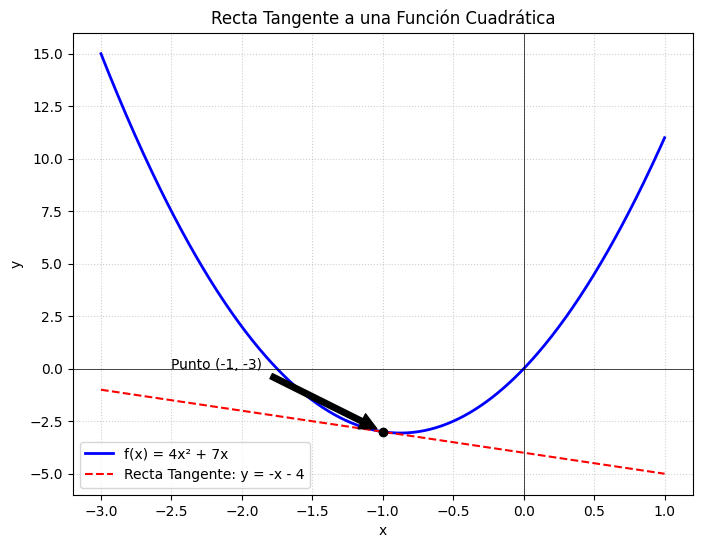

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir la función y su tangente para graficar
def f_np(x): return 4*x**2 + 7*x
def tangent_np(x): return -x - 4

# Crear rango de valores para x
x_vals = np.linspace(-3, 1, 400)
y_f = f_np(x_vals)
y_t = tangent_np(x_vals)

# Configuración de la gráfica
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_f, label='f(x) = 4x² + 7x', color='blue', linewidth=2)
plt.plot(x_vals, y_t, label='Recta Tangente: y = -x - 4', color='red', linestyle='--')

# Marcar el punto de tangencia
plt.scatter([-1], [-3], color='black', zorder=5)
plt.annotate('Punto (-1, -3)', xy=(-1, -3), xytext=(-2.5, 0),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Estética de la gráfica
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.title('Recta Tangente a una Función Cuadrática')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\recta_tangente_a_cuadratica.png")
plt.show()


## ¿Qué está pasando matemáticamente?
La derivada $f'(x) = 8x + 7$ nos da la "velocidad" de cambio en cualquier punto. Al evaluar en $x = -1$, nos dice que la curva baja con una inclinación de $-1$. Por eso, la recta roja apenas toca a la parábola azul en ese punto exacto antes de que la curva vuelva a subir.